## Ghi chú

Bộ dữ liệu phân loại giả lập (`make_classification`, 4 lớp) dùng để so sánh các kỹ thuật:

- **Learning curve** của `DecisionTreeClassifier` — theo dõi score train/CV theo kích thước tập huấn luyện để nhận biết underfit/overfit.
- **K-Fold vs Stratified K-Fold** — so sánh độ ổn định của accuracy giữa hai chiến lược CV.
- **Grid Search vs Random Search** — tìm `max_depth`/`criterion` tốt nhất cho Decision Tree, rồi mở rộng sang Random Forest (`n_estimators`, `min_samples_leaf`).
- So sánh Decision Tree (dễ overfit, train acc = 1.0) với Random Forest (test acc cao hơn nhờ bagging nhiều cây).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve, train_test_split

# 1. Sinh bộ dữ liệu mô phỏng cho bài toán phân loại
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0,
                           n_classes=4, n_clusters_per_class=1, random_state=42)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (350, 10)
Kích thước tập kiểm tra: (150, 10)


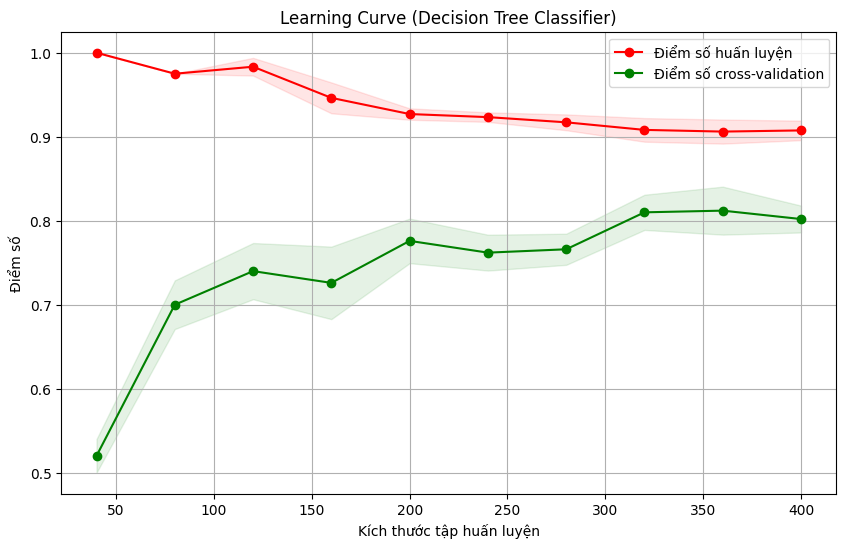

In [16]:
# 2. Khởi tạo mô hình cây quyết định
estimator = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')

# 3. Vẽ learning curve
# Tính toán learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Tính trung bình và độ lệch chuẩn của các điểm số
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Decision Tree Classifier)")
plt.xlabel("Kích thước tập huấn luyện")
plt.ylabel("Điểm số")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Điểm số huấn luyện")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Điểm số cross-validation")

plt.legend(loc="best")
plt.show()

In [5]:
print(f"Unique classes in y: {np.unique(y)}")

Unique classes in y: [0 1 2 3]



--- So sánh K-fold và Stratified K-fold ---
K-Fold Cross-Validation Accuracy: 0.8000 (+/- 0.0415)
Stratified K-Fold Cross-Validation Accuracy: 0.8040 (+/- 0.0307)


/tmp/ipykernel_4034/2030406726.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kf_scores, skf_scores], labels=['K-Fold', 'Stratified K-Fold'])


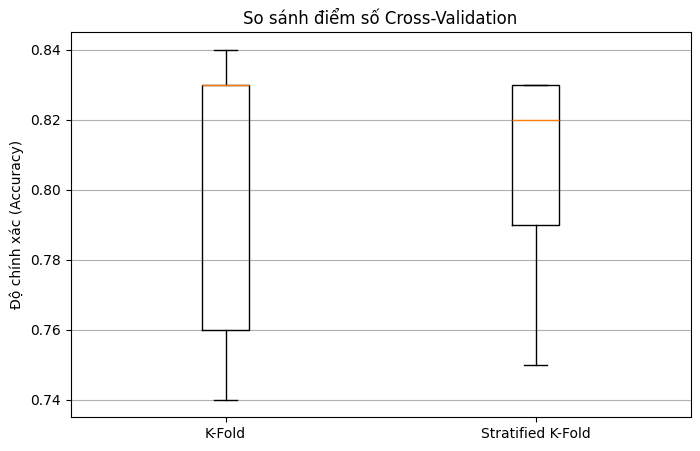

In [17]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

# 4. So sánh K-fold và Stratified K-fold
print("\n--- So sánh K-fold và Stratified K-fold ---")

# Khởi tạo mô hình cây quyết định (sử dụng estimator đã có)
# estimator = DecisionTreeClassifier(random_state=42)

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(estimator, X, y, cv=kf, scoring='accuracy')

print(f"K-Fold Cross-Validation Accuracy: {kf_scores.mean():.4f} (+/- {kf_scores.std():.4f})")

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(estimator, X, y, cv=skf, scoring='accuracy')

print(f"Stratified K-Fold Cross-Validation Accuracy: {skf_scores.mean():.4f} (+/- {skf_scores.std():.4f})")

# So sánh trực quan
plt.figure(figsize=(8, 5))
plt.boxplot([kf_scores, skf_scores], labels=['K-Fold', 'Stratified K-Fold'])
plt.title('So sánh điểm số Cross-Validation')
plt.ylabel('Độ chính xác (Accuracy)')
plt.grid(axis='y')
plt.show()


In [32]:
from sklearn.linear_model import LogisticRegression

print("--- Huấn luyện mô hình Logistic Regression ---")

# Khởi tạo mô hình Logistic Regression
logistic_model = LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Huấn luyện mô hình
logistic_model.fit(X_train, y_train)

# Đánh giá độ chính xác trên tập kiểm tra
logistic_accuracy = logistic_model.score(X_test, y_test)
print(f"Độ chính xác của Logistic Regression trên tập kiểm tra: {logistic_accuracy:.4f}")

--- Huấn luyện mô hình Logistic Regression ---
Độ chính xác của Logistic Regression trên tập kiểm tra: 0.8333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [23]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

print("\n--- So sánh Grid Search và Random Search cho max_depth, min_samples_leaf, criterion ---")

# Khởi tạo lại estimator cơ bản (không có max_depth cụ thể để tìm kiếm)
basic_estimator = DecisionTreeClassifier(random_state=42)

# Định nghĩa không gian tham số cho Grid Search
param_grid = {
    'max_depth': list(range(4, 16)),
    # 'min_samples_leaf': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

# KFold chiến lược cross-validation (có thể dùng skf đã định nghĩa trước đó nếu muốn)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Re-using skf from previous cell

# 1. Grid Search
print("\nChạy Grid Search...")
grid_search = GridSearchCV(basic_estimator, param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Grid Search - Best parameters: {grid_search.best_params_}")
print(f"Grid Search - Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# 2. Random Search
print("\nChạy Random Search...")
# Định nghĩa không gian tham số cho Random Search
# Sử dụng các danh sách tương tự để so sánh trực tiếp
param_distributions = {
    'max_depth': list(range(4, 16)),
    # 'min_samples_leaf': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

# Tổng số kết hợp trong Grid Search là 7 * 4 * 2 = 56
# Chọn n_iter = 20 để khám phá một phần đáng kể không gian này
random_search = RandomizedSearchCV(basic_estimator, param_distributions, n_iter=20, cv=cv_strategy,
                                   scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"Random Search - Best parameters: {random_search.best_params_}")
print(f"Random Search - Best cross-validation accuracy: {random_search.best_score_:.4f}")

print("\n--- So sánh kết quả --- ")
print(f"Grid Search tìm thấy tham số tốt nhất: {grid_search.best_params_} với độ chính xác {grid_search.best_score_:.4f}")
print(f"Random Search tìm thấy tham số tốt nhất: {random_search.best_params_} với độ chính xác {random_search.best_score_:.4f}")

# So sánh hiệu suất trên tập kiểm tra với tham số tốt nhất
grid_best_estimator = grid_search.best_estimator_
random_best_estimator = random_search.best_estimator_

grid_test_accuracy = grid_best_estimator.score(X_test, y_test)
random_test_accuracy = random_best_estimator.score(X_test, y_test)

print(f"\nĐộ chính xác trên tập kiểm tra (Grid Search): {grid_test_accuracy:.4f}")
print(f"Độ chính xác trên tập kiểm tra (Random Search): {random_test_accuracy:.4f}")


--- So sánh Grid Search và Random Search cho max_depth, min_samples_leaf, criterion ---

Chạy Grid Search...
Grid Search - Best parameters: {'criterion': 'entropy', 'max_depth': 10}
Grid Search - Best cross-validation accuracy: 0.8029

Chạy Random Search...
Random Search - Best parameters: {'max_depth': 10, 'criterion': 'entropy'}
Random Search - Best cross-validation accuracy: 0.8029

--- So sánh kết quả --- 
Grid Search tìm thấy tham số tốt nhất: {'criterion': 'entropy', 'max_depth': 10} với độ chính xác 0.8029
Random Search tìm thấy tham số tốt nhất: {'max_depth': 10, 'criterion': 'entropy'} với độ chính xác 0.8029

Độ chính xác trên tập kiểm tra (Grid Search): 0.7533
Độ chính xác trên tập kiểm tra (Random Search): 0.7533


In [27]:
estimator = DecisionTreeClassifier(random_state=42)
estimator.fit(X_train, y_train)
print(estimator.score(X_test, y_test))

0.8133333333333334


In [28]:
estimator.score(X_train, y_train)

1.0

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Evaluate the model on the test set
rf_accuracy = rf_classifier.score(X_test, y_test)
print(f"Accuracy of Random Forest Classifier on the test set: {rf_accuracy:.4f}")

Accuracy of Random Forest Classifier on the test set: 0.8400


In [30]:
rf_classifier.score(X_train, y_train)

1.0

In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

print("--- Tìm kiếm tham số tốt nhất cho Random Forest --- ")

# Khởi tạo mô hình Random Forest cơ bản
rf_basic_estimator = RandomForestClassifier(random_state=42)

# Định nghĩa không gian tham số cho Grid Search
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None], # None nghĩa là độ sâu tối đa không giới hạn
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Sử dụng chiến lược cross-validation đã định nghĩa trước đó (StratifiedKFold)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Grid Search cho Random Forest
print("\nChạy Grid Search cho Random Forest...")
grid_search_rf = GridSearchCV(rf_basic_estimator, param_grid_rf, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"Grid Search RF - Best parameters: {grid_search_rf.best_params_}")
print(f"Grid Search RF - Best cross-validation accuracy: {grid_search_rf.best_score_:.4f}")

# 2. Random Search cho Random Forest
print("\nChạy Random Search cho Random Forest...")
# Định nghĩa không gian tham số cho Random Search
param_distributions_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 20), # Hoặc sử dụng [5, 10, 15, None] với các giá trị cụ thể
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

random_search_rf = RandomizedSearchCV(rf_basic_estimator, param_distributions_rf, n_iter=30, cv=cv_strategy,
                                    scoring='accuracy', random_state=42, n_jobs=-1)
random_search_rf.fit(X_train, y_train)

print(f"Random Search RF - Best parameters: {random_search_rf.best_params_}")
print(f"Random Search RF - Best cross-validation accuracy: {random_search_rf.best_score_:.4f}")

print("\n--- So sánh kết quả của Grid Search và Random Search cho Random Forest --- ")
print(f"Grid Search RF tìm thấy tham số tốt nhất: {grid_search_rf.best_params_} với độ chính xác {grid_search_rf.best_score_:.4f}")
print(f"Random Search RF tìm thấy tham số tốt nhất: {random_search_rf.best_params_} với độ chính xác {random_search_rf.best_score_:.4f}")

# So sánh hiệu suất trên tập kiểm tra với tham số tốt nhất
grid_best_estimator_rf = grid_search_rf.best_estimator_
random_best_estimator_rf = random_search_rf.best_estimator_

grid_test_accuracy_rf = grid_best_estimator_rf.score(X_test, y_test)
random_test_accuracy_rf = random_best_estimator_rf.score(X_test, y_test)

print(f"\nĐộ chính xác trên tập kiểm tra (Grid Search RF): {grid_test_accuracy_rf:.4f}")
print(f"Độ chính xác trên tập kiểm tra (Random Search RF): {random_test_accuracy_rf:.4f}")

--- Tìm kiếm tham số tốt nhất cho Random Forest --- 

Chạy Grid Search cho Random Forest...
Grid Search RF - Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 150}
Grid Search RF - Best cross-validation accuracy: 0.8629

Chạy Random Search cho Random Forest...
Random Search RF - Best parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 2, 'n_estimators': 181}
Random Search RF - Best cross-validation accuracy: 0.8629

--- So sánh kết quả của Grid Search và Random Search cho Random Forest --- 
Grid Search RF tìm thấy tham số tốt nhất: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 150} với độ chính xác 0.8629
Random Search RF tìm thấy tham số tốt nhất: {'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 2, 'n_estimators': 181} với độ chính xác 0.8629

Độ chính xác trên tập kiểm tra (Grid Search RF): 0.8533
Độ chính xác trên tập kiểm tra (Random Search RF): 0.8533
